In [14]:
import uxarray as ux
import xarray as xr
import numpy as np
import geocat.datafiles as gdf
import geocat.comp as gc
import geocat.datafiles as gdf
import matplotlib.pyplot as plt

In [3]:
data_path = 'netcdf_files/e2p3b09.F2000climo.ne30pg3.ctl002.cam.h0.0005-01.zonal_mpsi_subset.nc'
grid_path = 'netcdf_files/ne30pg3_scrip_170604.nc'

uxds = ux.open_dataset(gdf.get(grid_path), gdf.get(data_path)).drop('lat')
uxds

/var/folders/dd/_xm_pbpd3flgbvbnt7qhd70snnbpj_/T/ipykernel_59877/3817423852.py:4: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  uxds = ux.open_dataset(gdf.get(grid_path), gdf.get(data_path)).drop('lat')


<xarray.UxDataset> Size: 6MB
Dimensions:  (time: 1, n_face: 48600, lev: 32, ilev: 33)
Coordinates:
  * time     (time) object 8B 0005-02-01 00:00:00
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * ilev     (ilev) float64 264B 2.255 5.032 10.16 18.56 ... 967.5 985.1 1e+03
Dimensions without coordinates: n_face
Data variables:
    PS       (time, n_face) float32 194kB ...
    V        (time, lev, n_face) float32 6MB ...
    hyam     (lev) float64 256B ...
    hybm     (lev) float64 256B ...
    hyai     (ilev) float64 264B ...
    hybi     (ilev) float64 264B ...

In [4]:
da_ipress = gc.interpolation.interp_hybrid_to_pressure(
    uxds.V, 
    uxds.PS, 
    uxds.hyam, 
    uxds.hybm)
da_ipress

/Users/jkent/Documents/GeoCAT/geocat-comp/geocat/comp/interpolation.py:721: UserWarning: Interpolation point out of data bounds encountered
  output = func_interpolate(


<xarray.DataArray 'V' (time: 1, plev: 21, n_face: 48600)> Size: 8MB
array([[[-1.55059624, -1.51337405, -1.62205671, ...,         nan,
                 nan,         nan],
        [-1.88792149, -1.96537218, -2.21956085, ..., -0.64867409,
         -0.97216295, -1.33857767],
        [-2.02417783, -2.15568237, -2.37787909, ..., -0.6517731 ,
         -1.15500701, -1.54386502],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]], shape=(1, 21, 48600))
Coordinates:
  * time     (time) object 8B 0005-02-01 00:00:00
  * plev     (plev) float32 84B 1e+05 9.25e+04 8.5e+04 ... 300.0 200.0 100.0
Dimensions without coordinates: n_face
Attributes:
    mdims:         1
    units:         m/s
    long_name:     Meridional wind
    cell_methods:  time: mean

In [5]:
ux_ipress = ux.UxDataArray(da_ipress, uxgrid=uxds.uxgrid)
ux_ipress 

<xarray.UxDataArray 'V' (time: 1, plev: 21, n_face: 48600)> Size: 8MB
array([[[-1.55059624, -1.51337405, -1.62205671, ...,         nan,
                 nan,         nan],
        [-1.88792149, -1.96537218, -2.21956085, ..., -0.64867409,
         -0.97216295, -1.33857767],
        [-2.02417783, -2.15568237, -2.37787909, ..., -0.6517731 ,
         -1.15500701, -1.54386502],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]], shape=(1, 21, 48600))
Coordinates:
  * time     (time) object 8B 0005-02-01 00:00:00
  * plev     (plev) float32 84B 1e+05 9.25e+04 8.5e+04 ... 300.0 200.0 100.0
Dimensions without coordinates: n_face
Attributes:
    mdims:         1
    units:         m/s
    long_name:     Meridional wind
    cell_methods:  time: mean

In [6]:
# zonal mean wind
ux_v_zonal = ux_ipress.zonal_mean()
ux_v_zonal

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


<xarray.DataArray 'V_zonal_mean' (time: 1, plev: 21, latitudes: 19)> Size: 3kB
array([[[            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan],
        [            nan,             nan,             nan,
         -4.68842119e-01, -9.20753914e-01,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
          2.04907625e-02],
        [            nan,             nan,             nan,
         -5.05031908e-02, -2.25405356e-01, -1.63950973e-01,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
          2.03113264e-01,             nan,             nan,
...
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan],
        [            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan],
        [            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan]]])
Coordinates:
  * latitudes  (latitudes) float64 152B -90.0 -80.0 -70.0 ... 70.0 80.0 90.0
Dimensions without coordinates: time, plev
Attributes:
    zonal_mean:    True
    conservative:  False

In [7]:
ux_v_zonal['plev'] = ux_ipress.plev
ux_v_zonal

<xarray.DataArray 'V_zonal_mean' (time: 1, plev: 21, latitudes: 19)> Size: 3kB
array([[[            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan],
        [            nan,             nan,             nan,
         -4.68842119e-01, -9.20753914e-01,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
          2.04907625e-02],
        [            nan,             nan,             nan,
         -5.05031908e-02, -2.25405356e-01, -1.63950973e-01,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
          2.03113264e-01,             nan,             nan,
...
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan],
        [            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan],
        [            nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan,             nan,             nan,
                     nan]]])
Coordinates:
  * plev       (plev) float32 84B 1e+05 9.25e+04 8.5e+04 ... 300.0 200.0 100.0
  * latitudes  (latitudes) float64 152B -90.0 -80.0 -70.0 ... 70.0 80.0 90.0
Dimensions without coordinates: time
Attributes:
    zonal_mean:    True
    conservative:  False

In [9]:
ux_PS_zonal = uxds.PS.zonal_mean()
ux_PS_zonal

<xarray.DataArray 'PS_zonal_mean' (time: 1, latitudes: 19)> Size: 76B
array([[ 67811.09 ,  78607.555,  89532.234,  98368.2  , 100244.914,
        101444.77 , 100448.18 ,  99279.34 ,  99575.53 ,  99954.55 ,
         99828.26 ,  99917.07 ,  97050.13 ,  96911.39 ,  97549.914,
         98085.555,  97363.945,  97557.445, 100496.2  ]], dtype=float32)
Coordinates:
  * latitudes  (latitudes) float64 152B -90.0 -80.0 -70.0 ... 70.0 80.0 90.0
Dimensions without coordinates: time
Attributes:
    zonal_mean:    True
    conservative:  False

In [10]:
# Constants
a = 6.371e6  # Earth radius (m)
g = 9.80665  # gravity (m/s^2)

lat = ux_v_zonal.latitudes
da_scaling_factor = 2 * np.pi * a * np.cos(lat) / g
da_scaling_factor

<xarray.DataArray 'latitudes' (latitudes: 19)> Size: 152B
array([-1829010.37924921,  -450594.29399683,  2585172.06576331,
       -3887694.26229467,  3938935.07272736, -2722402.28651777,
         629645.42589202,  1665767.18595934, -3425041.06550859,
        4081941.70201253, -3425041.06550859,  1665767.18595934,
         629645.42589202, -2722402.28651777,  3938935.07272736,
       -3887694.26229467,  2585172.06576331,  -450594.29399683,
       -1829010.37924921])
Coordinates:
  * latitudes  (latitudes) float64 152B -90.0 -80.0 -70.0 ... 70.0 80.0 90.0

In [11]:
np_dp_zonal = gc.meteorology.delta_pressure(ux_v_zonal.plev, ux_PS_zonal)
np_dp_zonal

<xarray.DataArray 'delta pressure' (time: 1, latitudes: 19, lev: 21)> Size: 3kB
array([[[          nan,           nan,           nan,  7811.09375  ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,   650.       ,
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ],
        [          nan,           nan,  1107.5546875, 17500.       ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,   650.       ,
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ],
        [          nan,   782.234375 , 11250.       , 17500.       ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,   650.       ,
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ],
        [ 2118.203125 ,  7500.       , 11250.       , 17500.       ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
...
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ],
        [ 1113.9453125,  7500.       , 11250.       , 17500.       ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,   650.       ,
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ],
        [ 1307.4453125,  7500.       , 11250.       , 17500.       ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,   650.       ,
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ],
        [ 4246.203125 ,  7500.       , 11250.       , 17500.       ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,   650.       ,
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ]]])
Coordinates:
  * latitudes  (latitudes) float64 152B -90.0 -80.0 -70.0 ... 70.0 80.0 90.0
  * lev        (lev) float32 84B 1e+05 9.25e+04 8.5e+04 ... 300.0 200.0 100.0
Dimensions without coordinates: time
Attributes:
    long name:  pressure layer thickness

In [12]:
da_dp_zonal = xr.DataArray(
    np_dp_zonal,
    dims=["time", "latitudes", "plev"],
    coords={
        "plev": ux_v_zonal.plev,
        "latitudes": ux_v_zonal.latitudes
        },
    name="delta_pressure"
)
ux_dp_zonal = ux.UxDataArray(da_dp_zonal, uxgrid=uxds.uxgrid)
ux_dp_zonal

<xarray.UxDataArray 'delta_pressure' (time: 1, latitudes: 19, plev: 21)> Size: 3kB
array([[[          nan,           nan,           nan,  7811.09375  ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,   650.       ,
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ],
        [          nan,           nan,  1107.5546875, 17500.       ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,   650.       ,
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ],
        [          nan,   782.234375 , 11250.       , 17500.       ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,   650.       ,
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ],
        [ 2118.203125 ,  7500.       , 11250.       , 17500.       ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
...
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ],
        [ 1113.9453125,  7500.       , 11250.       , 17500.       ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,   650.       ,
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ],
        [ 1307.4453125,  7500.       , 11250.       , 17500.       ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,   650.       ,
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ],
        [ 4246.203125 ,  7500.       , 11250.       , 17500.       ,
         15000.       , 10000.       ,  7500.       ,  5000.       ,
          5000.       ,  5000.       ,  4000.       ,  2500.       ,
          2000.       ,  1500.       ,  1000.       ,   650.       ,
           250.       ,   200.       ,   150.       ,   100.       ,
            50.       ]]])
Coordinates:
  * latitudes  (latitudes) float64 152B -90.0 -80.0 -70.0 ... 70.0 80.0 90.0
  * plev       (plev) float32 84B 1e+05 9.25e+04 8.5e+04 ... 300.0 200.0 100.0
Dimensions without coordinates: time
Attributes:
    long name:  pressure layer thickness

In [13]:
# Reverse plev, integrate, then reverse back
integrand = ux_v_zonal * ux_dp_zonal
ux_mpsi = (
    integrand.isel(plev=slice(None, None, -1))  # reverse plev: now top is first
    .cumsum(dim="plev")
)
ux_mpsi = ux_mpsi * da_scaling_factor
ux_mpsi

<xarray.DataArray (time: 1, plev: 21, latitudes: 19)> Size: 3kB
array([[[-0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
         -0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
          0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
          0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
          0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
         -0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
         -0.00000000e+00],
        [-0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
         -0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
          0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
          0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
          0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
         -0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
         -0.00000000e+00],
        [-0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
         -0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
          0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
          0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
          0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
         -0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
...
         -1.01250548e+10,  4.40204624e+10, -1.38682361e+10,
         -4.98778264e+09, -1.26306209e+10, -1.89604151e+10,
          1.03816756e+11, -1.80356590e+11,  5.16441431e+10,
         -5.95418336e+07,  3.02221685e+10, -4.47582232e+10,
          2.12409304e+10,  2.39023895e+09, -7.91708424e+08,
          8.14999587e+08],
        [ 6.93545961e+08, -4.30908241e+08, -1.54112498e+10,
          3.54530635e+09,  1.68195382e+10, -1.38682361e+10,
         -4.98778264e+09, -1.26306209e+10, -1.89604151e+10,
          1.03816756e+11, -1.80356590e+11,  5.16441431e+10,
         -5.95418336e+07,  3.02221685e+10, -4.47582232e+10,
          2.12409304e+10,  2.39023895e+09, -7.91708424e+08,
          5.33915957e+08],
        [ 6.93545961e+08, -4.30908241e+08, -1.54112498e+10,
          3.54530635e+09,  1.68195382e+10, -1.38682361e+10,
         -4.98778264e+09, -1.26306209e+10, -1.89604151e+10,
          1.03816756e+11, -1.80356590e+11,  5.16441431e+10,
         -5.95418336e+07,  3.02221685e+10, -4.47582232e+10,
          2.12409304e+10,  2.39023895e+09, -7.91708424e+08,
          5.33915957e+08]]])
Coordinates:
  * plev       (plev) float32 84B 100.0 200.0 300.0 ... 8.5e+04 9.25e+04 1e+05
  * latitudes  (latitudes) float64 152B -90.0 -80.0 -70.0 ... 70.0 80.0 90.0
Dimensions without coordinates: time
Attributes:
    zonal_mean:    True
    conservative:  False
    long name:     pressure layer thickness

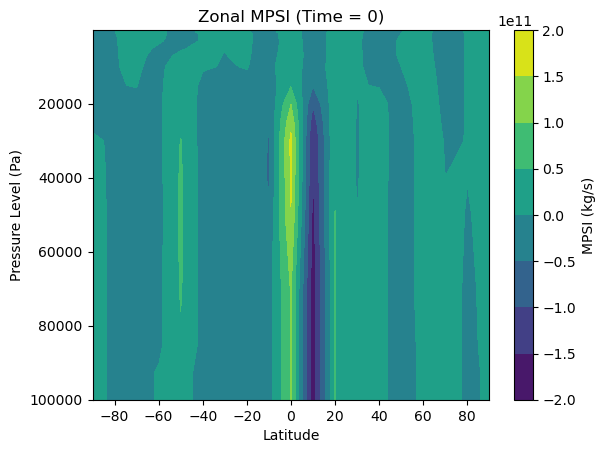

In [15]:
mpsi0 = ux_mpsi.isel(time=0)
plt.contourf(
    mpsi0['latitudes'],
    mpsi0['plev'],
    mpsi0
)
plt.xlabel("Latitude")
plt.ylabel("Pressure Level (Pa)")
plt.gca().invert_yaxis()
plt.colorbar(label="MPSI (kg/s)")
plt.title("Zonal MPSI (Time = 0)")
plt.show()